<a href="https://colab.research.google.com/github/michelleabraham-git/Stats_minor/blob/main/CSSL_10_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

Let's load the Iris dataset

In [2]:
iris = load_iris()
X_raw = pd.DataFrame(iris.data[:, :4], columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])
y_raw = iris.target
type(iris)

sklearn.utils._bunch.Bunch

Use the below function for plotting. The data that is passed needs to be a pandas dataframe.

In [3]:
# Plotting function
def scatter_helper(data, x_axis_column_name, y_axis_column_name, encoded_class_labels, title):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=data, x=x_axis_column_name, y=y_axis_column_name, hue=encoded_class_labels, palette='viridis', s=70)
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

1. Scale the X_raw using StandardScaler
2. Encode y values using label encoder

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

3. Scatter the original scaled data along any two features using the above plotting function. Try this step for different combinations of features and identify which pairs of features show correlations. You can use the scatter_helper I have defined above.

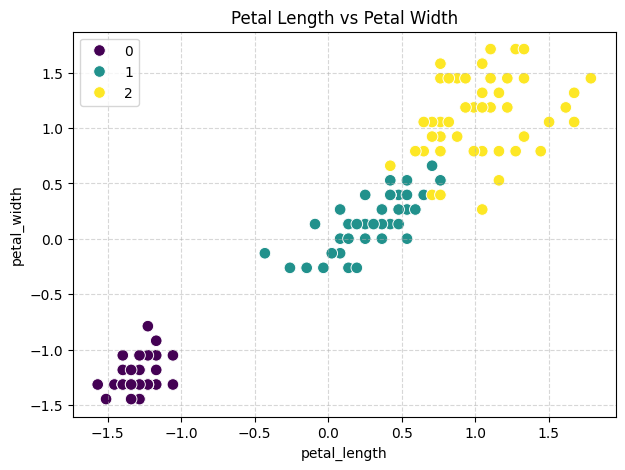

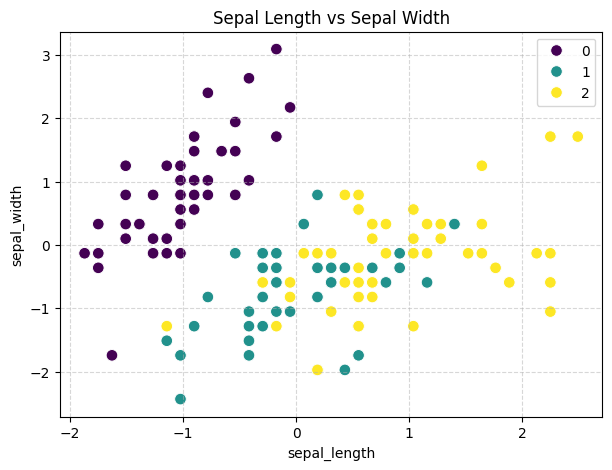

In [15]:
X_scaled_df = pd.DataFrame(X, columns=X_raw.columns)

# Petal Length vs Petal Width
scatter_helper(
    data=X_scaled_df,
    x_axis_column_name='petal_length',
    y_axis_column_name='petal_width',
    encoded_class_labels=y,
    title='Petal Length vs Petal Width'
)

#  Sepal Length vs Sepal Width
scatter_helper(
    data=X_scaled_df,
    x_axis_column_name='sepal_length',
    y_axis_column_name='sepal_width',
    encoded_class_labels=y,
    title='Sepal Length vs Sepal Width'
)



4. Create a PCA model containing as many components as the number of features. Fit-transform the model with the scaled X data.
5. Create a dataframe with the X_pca. Ensure that your give names to different columns, i.e., "PC1", "PC2"...

In [18]:
pca_model = PCA(n_components = X.shape[1])
X_pca = pca_model.fit_transform(X)

column_names = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_X_pca = pd.DataFrame(data = X_pca, columns = column_names)

5. Scatter the datapoints in the new space with PC1 and PC2 as the new axis. Again, you can take help of the scatter_helper defined above.

**Note:** The y values haven't changed because the class labels aren't used in PCA since it is an unsupervised learning method.

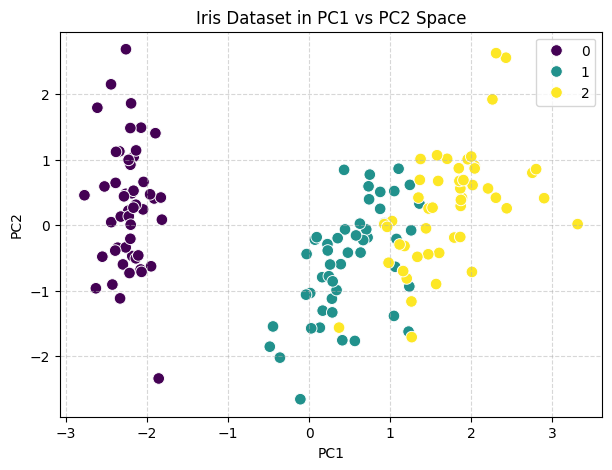

In [19]:
scatter_helper(
    data=df_X_pca,
    x_axis_column_name='PC1',
    y_axis_column_name='PC2',
    encoded_class_labels=y,
    title='Iris Dataset in PC1 vs PC2 Space'
)

6. Plot the scree plot to look at the proportion of variance captured by each PC. In addition, you can plot the cumulative proportion or variance captured by the first n PCs in the same plot using np.cumsum and plt.step

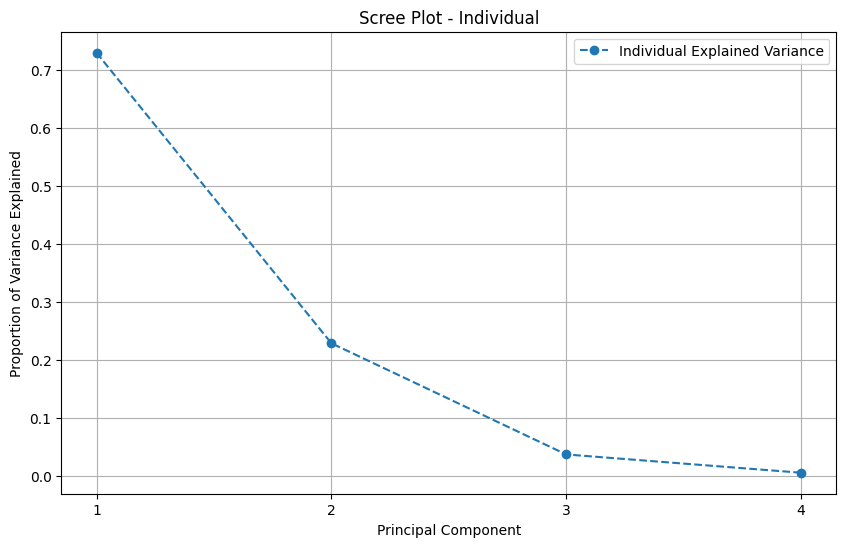

NameError: name 'np' is not defined

In [22]:
#INDIVIDUAL
explained_variance_ratio = pca_model.explained_variance_ratio_

plt.figure(figsize=(10, 6))

# Scree plot for individual explained variance
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Individual Explained Variance')

plt.title('Scree Plot - Individual')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(True)
plt.legend()
plt.show()

#CUMULATIVE
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))

# Scree plot for individual explained variance
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='--', label='Cumulative Explained Variance')

plt.title('Scree Plot - Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(range(1, len(Cumulative_variance_ratio) + 1))
plt.grid(True)
plt.legend()
plt.show()


7. Extract the loadings of the components, tranpose them, and visualize them using a heatmap. The seaborn library can be used for visualization.

In [ ]:
loadings = pd.DataFrame(
    , # transposed PCA components
    columns=,
    index=   # use the feature names form the iris dataset
)

plt.show()


8. Reconstruct the scaled X values from the first two principal components. Hint: Check inverse_transform function from the PCA model

9. Scatter plot pairs of the reconstructed values of the different features (petal length, petal width, sepal length, sepal width). Assess how they compare with the original scaled X values.

10. Compare the mean squared error (reconstruction error) between the original scaled X values and the reconstructed X values.